Module 7: Unsupervised Machine Learning

Theoretical Assignments:
1. Explain Clustering algorithms and their use cases
2. Presentation: Model Evaluation techniques in Unsupervised Learning
Practical Tasks

Task 1: Customer Segmentation

Dataset: https://www.kaggle.com/datasets/vishakhdapat/customer-segmentation- clustering/data
Customer Personality Analysis is a detailed analysis of a company’s ideal customers. It
helps a business to better understand its customers and makes it easier for themtomodify products according to the specific needs, behaviours and concerns of different
types of customer segments. Do as directed

1. Find Customer segments using K-means clustering algorithm. 

2. Find Customer segments using Hierarchical clustering algorithm. 

3. Compare the Clusters and conclude your analysis.

In [17]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
df = pd.read_csv('customer_segmentation.csv')
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,43,182,42,118,247,2,9,3,4,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,0,30,0,0,8,7,8,2,5,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,48,217,32,12,24,1,2,3,13,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,30,214,80,30,61,2,6,5,10,3,0,0,0,0,0,0,3,11,0


In [20]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

In [19]:
df['Income'] = df['Income'].fillna(df['Income'].mean())

In [21]:
import numpy as np
X = df.select_dtypes(include=np.number)

In [22]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [23]:
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i,random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

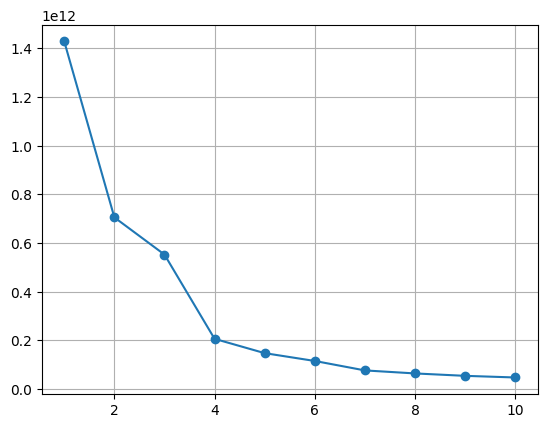

In [25]:
import matplotlib.pyplot as plt
plt.plot(range(1,11),wcss,marker='o')
plt.grid()

In [26]:
kmeans = KMeans(n_clusters=4,random_state=42)
y_means = kmeans.fit_predict(X_scaled)

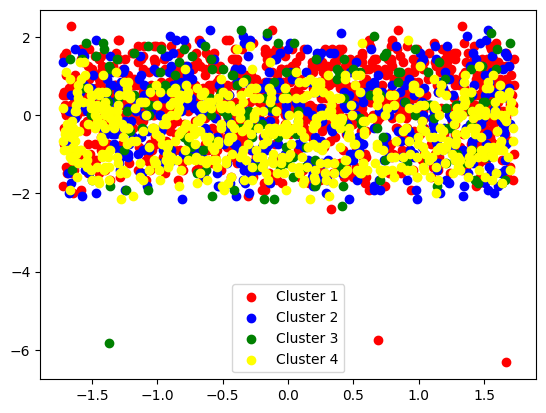

In [28]:
plt.scatter(X_scaled[y_means==0,0],
            X_scaled[y_means==0,1],
            color='red',
            label='Cluster 1')
plt.scatter(X_scaled[y_means==1,0],
            X_scaled[y_means==1,1],
            color='blue',
            label='Cluster 2')
plt.scatter(X_scaled[y_means==2,0],
            X_scaled[y_means==2,1],
            color='green',
            label='Cluster 3')
plt.scatter(X_scaled[y_means==3,0],
            X_scaled[y_means==3,1],
            color='yellow',
            label='Cluster 4')

plt.legend()
plt.show()